# [WEEK 3] [Time Series] 과제

## 과제 목적

이번 과제는 세션에서 다룬 내용을 **하나의 데이터에 처음부터 끝까지 적용**해 보는 것을 목적으로 합니다.
`시계열 구성요소 확인 → 정상성 진단과 차분 → ACF/PACF로 차수 결정 → SARIMA → LSTM → DLinear → 평가·검증` 순서로 진행하며, **앞 단계의 결과가 뒤 단계의 입력이 되는 구조**입니다.
단순히 모델을 구현하는 데서 끝내지 않고, **완전히 동일한 평가 조건 위에서 성격이 다른 모델 세 가지를 비교하고 차이가 왜 발생했는지 해석**하는 데 초점을 둡니다.

---

### 사용 데이터: ETT (Electricity Transformer Dataset)

- **전력 변압기**에서 2016-07 ~ 2018-06까지 **1시간 간격**으로 수집한 데이터입니다. (17,420시점 × 7변수)
- 이 데이터는 세션에서 다룬 **LTSF-Linear / DLinear 논문이 사용한 벤치마크 데이터셋 중 하나**입니다.
  (데이터 원 출처는 `Informer, AAAI 2021` — https://arxiv.org/abs/2012.07436 )
- 저장소: https://github.com/zhouhaoyi/ETDataset

| 변수 | 의미 |
|---|---|
| HUFL / HULL | High UseFul Load / High UseLess Load |
| MUFL / MULL | Middle UseFul Load / Middle UseLess Load |
| LUFL / LULL | Low UseFul Load / Low UseLess Load |
| OT | Oil Temperature (변압기 유온) |

---
# 0. 환경 설정

In [1]:
!pip install -q statsmodels

import warnings, hashlib, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


In [2]:
# 데이터 로드 (ETDataset 저장소에서 직접 read)
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(URL, parse_dates=["date"]).set_index("date")
df = df.asfreq("h")          # 시간 단위 주기 명시

print("shape :", df.shape)
print("기간  :", df.index.min(), "~", df.index.max())
print("결측치 :", df.isna().sum().sum())
df.head()

shape : (17420, 7)
기간  : 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00
결측치 : 0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


### 0-1. 본인 실험 조건 배정

`NAME` 에 **본인 이름**을 입력하세요. 이름을 해시해 **분석 대상 변수**와 **랜덤 시드**가 자동 배정됩니다.

> ⚠️ 이 값에 따라 이후 모든 결과가 달라집니다.

In [3]:
NAME = "주희찬"       # TODO: 본인 이름 (예: "홍길동")

SEED   = int(hashlib.sha256(NAME.encode()).hexdigest(), 16) % 10000
COLS   = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
TARGET = COLS[SEED % 7]

np.random.seed(SEED); torch.manual_seed(SEED)

print(f"이름      : {NAME}")
print(f"SEED      : {SEED}")
print(f"분석 대상 : {TARGET}")

y = df[TARGET].astype(float)
print(f"\n시계열 길이: {len(y)},  결측: {y.isna().sum()}")
y.describe()

이름      : 주희찬
SEED      : 3226
분석 대상 : OT

시계열 길이: 17420,  결측: 0


,OT
count,17420.000000
mean,13.324672
std,8.566946
min,-4.080000
25%,6.964000
50%,11.396000
75%,18.079000
max,46.007000


---
# 1. 필수 과제

```
구성요소 확인 → 정상성 진단 → 차분 → 차수 결정 → 평가 프로토콜
   → 베이스라인 → SARIMA → LSTM → DLinear → 비교·해석
```

## 1-1. 시계열 구성 요소와 자기상관성

세션에서 시계열은 **추세 / 계절성 / 순환 / 잔차** 네 가지로 구성되고,
**자기상관성 · 정상성 · 변동성** 세 가지 특징을 갖는다고 배웠습니다.
실제 데이터에서 확인해 봅니다.

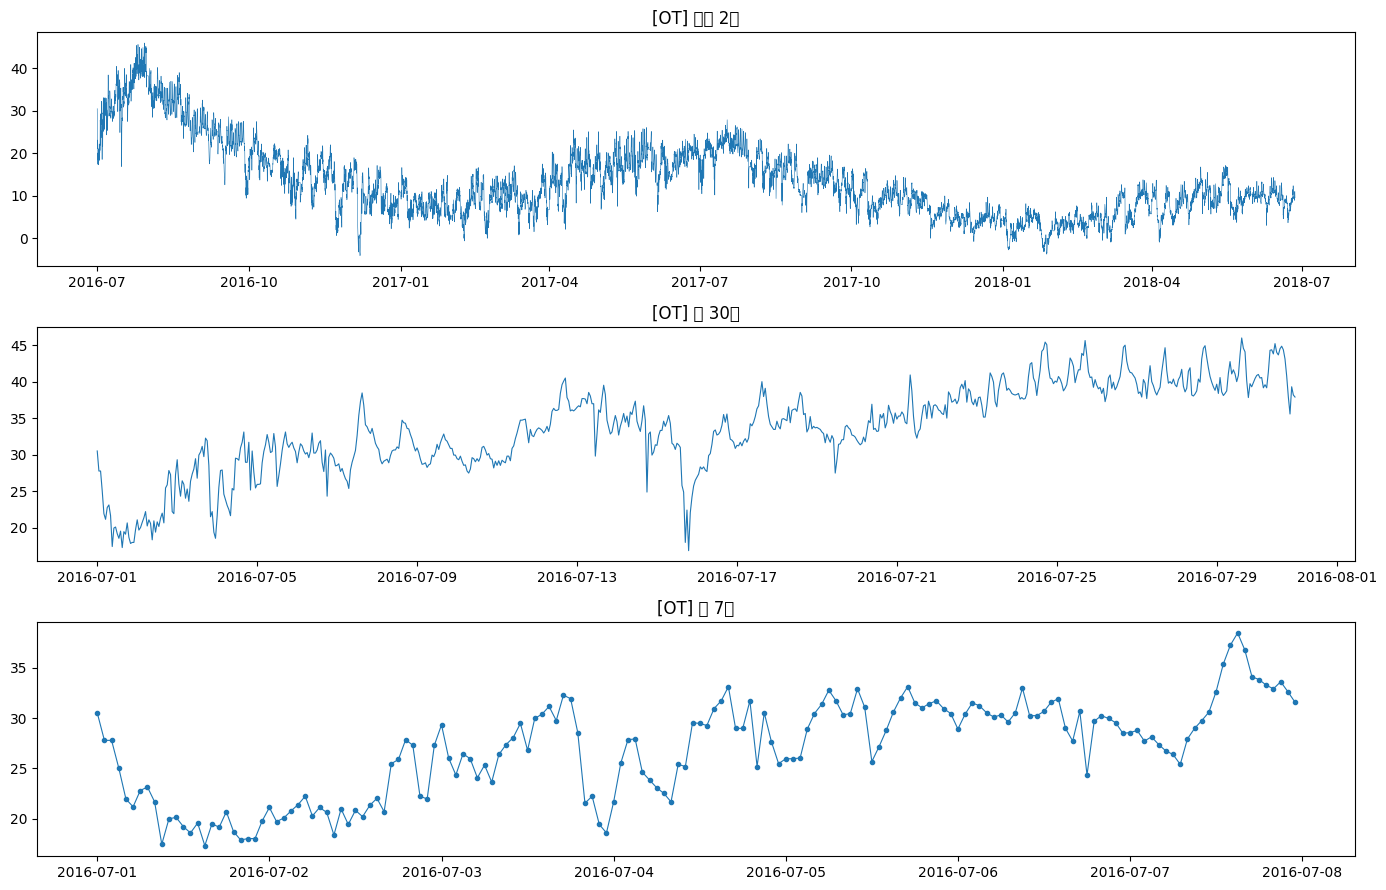

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(y.index, y.values, lw=0.4);                      axes[0].set_title(f"[{TARGET}] 전체 2년")
axes[1].plot(y.index[:24*30], y.values[:24*30], lw=0.8);      axes[1].set_title(f"[{TARGET}] 첫 30일")
axes[2].plot(y.index[:24*7], y.values[:24*7], marker=".", lw=0.8); axes[2].set_title(f"[{TARGET}] 첫 7일")
plt.tight_layout(); plt.show()

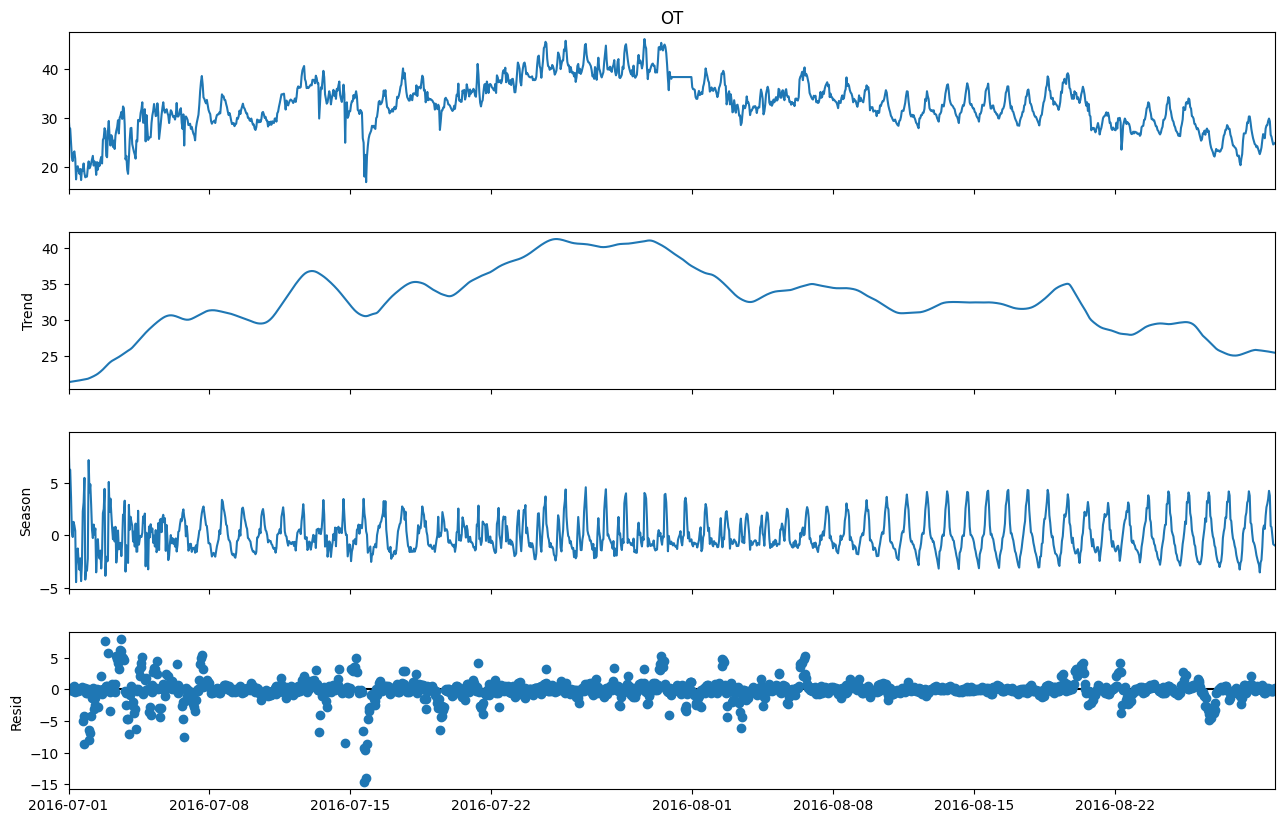

In [5]:
# 구성요소를 눈으로 분리해 봅니다.
# TODO: 이 데이터는 '시간 단위'입니다. 하루 주기를 잡으려면 period에 무엇을 넣어야 할까요?
PERIOD = 24

fig = STL(y.iloc[:24*60], period=PERIOD, robust=True).fit().plot()
fig.set_size_inches(14, 9); plt.show()

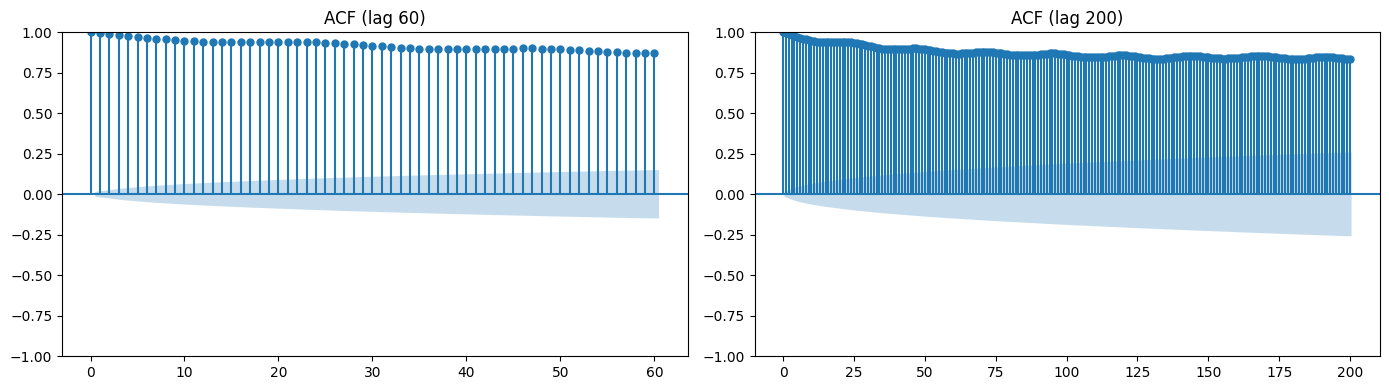

  ACF(lag=  1) = 0.994
  ACF(lag= 24) = 0.940
  ACF(lag= 48) = 0.900
  ACF(lag=168) = 0.856


In [6]:
# 자기상관성 확인 : 며칠 전 값이 현재와 얼마나 닮아 있는가
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y.dropna(), lags=60,  ax=axes[0]); axes[0].set_title("ACF (lag 60)")
plot_acf(y.dropna(), lags=200, ax=axes[1]); axes[1].set_title("ACF (lag 200)")
plt.tight_layout(); plt.show()

def acf_at(s, lag):
    # ACF(k) = 시차 k만큼 떨어진 값들의 공분산 / 전체 분산
    x = np.asarray(s.dropna(), float)
    x = x - x.mean()                      # 평균을 빼서 편차로 변환

    # TODO: ACF 정의를 떠올려 분자(공분산 부분)를 완성하세요.
    #          x[lag:]는 t=lag+1..N 시점, x[:-lag]는 t=1..N-lag 시점입니다.
    numerator = (x[lag:] * x[:-lag]).sum()

    return numerator / (x * x).sum()      # 분모는 전체 분산

for lag in [1, 24, 48, 168]:
    print(f"  ACF(lag={lag:3d}) = {acf_at(y, lag):.3f}")

## 1-2. 정상성 진단 — ADF 검정

세션에서 배운 ADF 검정을 그대로 적용합니다.

| | 내용 |
|---|---|
| 귀무가설 | 단위근이 존재한다 → **비정상 시계열** |
| 대립가설 | 단위근이 존재하지 않는다 → **정상 시계열** |
| p-value < 0.05 | 귀무가설 기각 → **정상 시계열** |
| p-value ≥ 0.05 | 귀무가설 채택 → **비정상 시계열** |

In [7]:
def adf_report(series, name):
    s = pd.Series(series).dropna()
    stat, p = adfuller(s)[0], adfuller(s)[1]

    # TODO: 세션에서 배운 ADF의 귀무가설을 떠올리며 부등호를 채우세요.
    verdict = "정상 시계열" if p < 0.05 else "비정상 시계열"

    print(f"[{name:16s}] ADF={stat:9.3f}  p={p:.4f}  ->  {verdict}")
    return p

adf_report(y, "원본")

[원본              ] ADF=   -3.488  p=0.0083  ->  정상 시계열


np.float64(0.008301649485465523)

> ### Q1.
> ADF 검정 결과 **원본 시계열이 "정상"** 으로 나왔을 것입니다.
> 그런데 1-1에서 그린 **ACF를 보면 lag 24, 48, 72마다 봉우리가 계속 반복**되고 있습니다.
>
> 1. "정상 시계열인데 자기상관이 강하게 남아 있다"는 것이 모순처럼 보입니다. 모순이 아닌 이유를 설명하세요.
>    (힌트: **자기상관성**과 **정상성**은 **서로 다른 특징**으로 소개되었습니다. 각각의 정의를 다시 확인해 보세요.)
> 2. 만약 ADF 결과만 보고 **"정상이니까 아무 처리 없이 바로 모델에 넣자"** 고 결론 내렸다면, 어떤 문제가 생길까요?

1. 정상성은 시계열 데이터의 평균이나 분산과 같은 특성이 시간의 흐름에 따라 변하지 않는 것이고, 자기상관성은 현재 값과 과거 값 사이의 상관관계 강도를 의미하는 서로 다른 개념이다. 따라서 전체적으로 평균과 분산이 안정적이더라고, 비슷한 주기가 반복되는 것이 가능하다.

2. 계절성이 반영되지 않아 모델의 잔차에 강한 자기상관이 남게 되어 예측 성능이 떨어지게 된다.

## 1-3. 차분(Differencing)

세션에서 **차분은 연이은 관측값들의 차이를 계산하는 것**이고, **추세나 계절성을 제거·감소**시킨다고 배웠습니다.

- **1차 차분** : $Y_t = X_t - X_{t-1}$
- **계절 차분** : $Y_t = X_t - X_{t-m}$  ($m$ = 계절 주기)

In [8]:
y_diff1 = y.diff()          # 1차 차분

# TODO: 하루 주기를 제거하는 계절 차분을 만드세요. (힌트: .diff(?) )
y_seas  = y.diff(24)

print("=" * 60)
adf_report(y,       "원본")
adf_report(y_diff1, "1차 차분")
adf_report(y_seas,  "계절 차분(lag 24)")
print("=" * 60)

[원본              ] ADF=   -3.488  p=0.0083  ->  정상 시계열
[1차 차분           ] ADF=  -26.383  p=0.0000  ->  정상 시계열
[계절 차분(lag 24)   ] ADF=  -23.901  p=0.0000  ->  정상 시계열


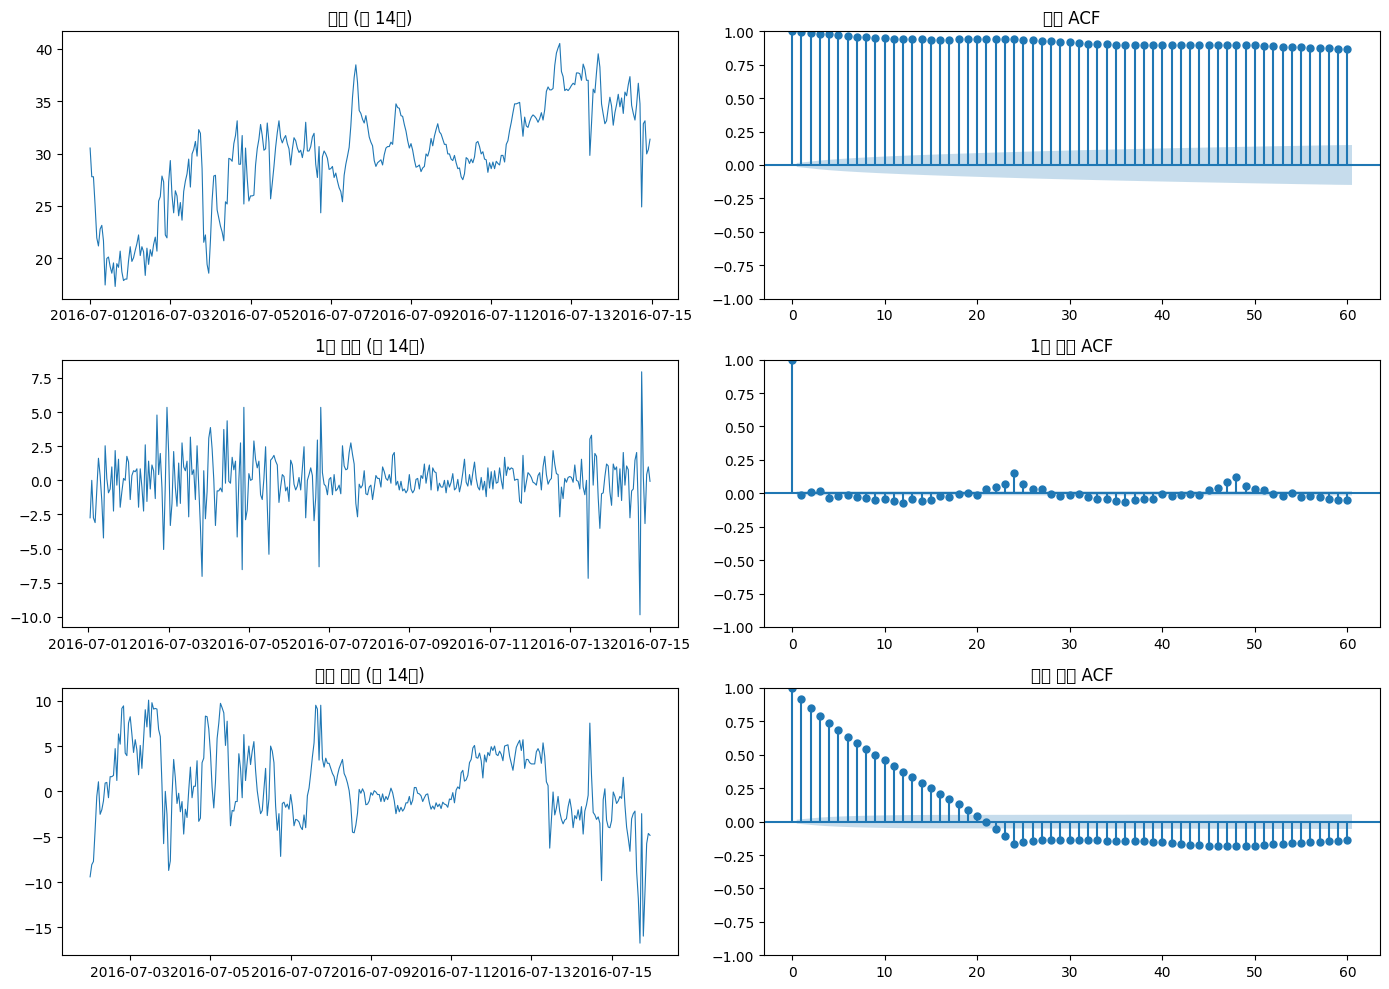

  원본           ACF(24) =   0.940
  1차 차분        ACF(24) =   0.154
  계절 차분        ACF(24) =  -0.169


In [9]:
# '차분 전 / 후' ACF를 비교합니다.
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, (s, name) in enumerate([(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]):
    s_ = s.dropna()
    axes[i, 0].plot(s_.index[:24*14], s_.values[:24*14], lw=0.8); axes[i, 0].set_title(f"{name} (앞 14일)")
    plot_acf(s_, lags=60, ax=axes[i, 1]);                          axes[i, 1].set_title(f"{name} ACF")
plt.tight_layout(); plt.show()

for s, name in [(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]:
    print(f"  {name:12s} ACF(24) = {acf_at(s, 24):7.3f}")

> ### Q2.
> 1. **계절 차분 후** ACF의 lag 24 값이 0 근처가 아니라 **음수로 크게** 나왔을 것입니다. 세션에서 차분의 목적은 "정상 시계열로 바꾸는 것"이었는데, 이 결과는 차분이 잘 된 것이라고 볼 수 있나요? 근거와 함께 쓰세요.
> 2. 위 결과를 종합해, 1-7에서 사용할 SARIMA의 **차분 차수 d 와 계절 차분 차수 D** 를 결정하고 근거를 서술하세요.

1. 계절 차분 후 ACF의 lag 24 값이 음수로 나온 것은 과대차분이 발생했다는 것이므로 차분이 잘 된 것이라고 볼 수 없다. 정상 시계열로 바꾸기 위해 필요 이상으로 차분을 진행하여 원래는 없었던 인위적인 자기상관 패턴을 만들어낸 상태이다.
2. 차분 차수 d=1, 계절 차분 차수 D=0이 적합하다. 1차 차분 만으로도 데이터가 정상 시계열이 되며, 계절 차분을 적용하면 과대차분 문제가 발생하기 때문이다.

## 1-4. ACF / PACF로 차수 결정

세션에서 배운 판별표입니다.

| 확률과정 | ACF | PACF |
|---|---|---|
| **AR(p)** | 지수적으로 감소하거나 감쇠 사인파 형태 | **시차 p 이후 0으로 절단** |
| **MA(q)** | **시차 q 이후 0으로 절단** | 지수적으로 감소하거나 감쇠 사인파 형태 |
| **ARMA(p,q)** | 절단 없이 감소 | 절단 없이 감소 |

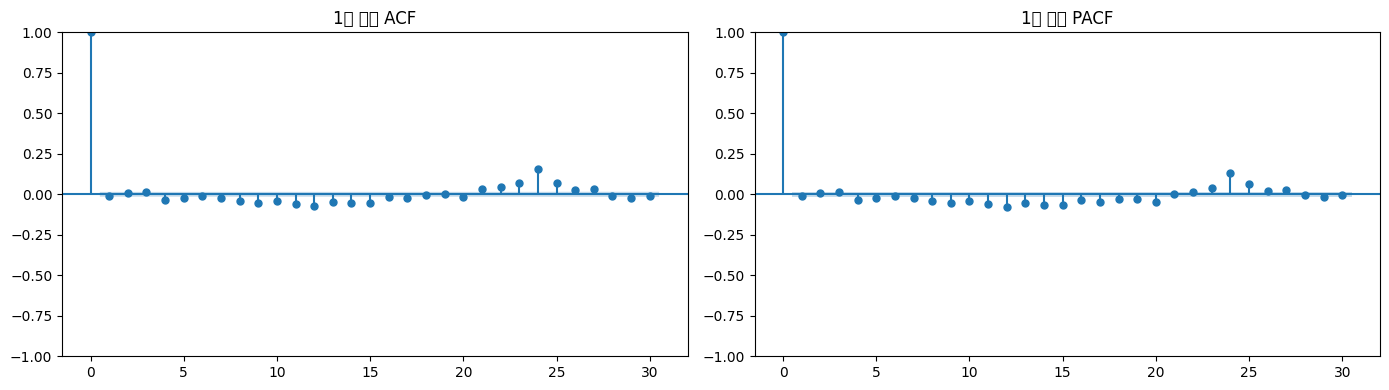

In [10]:
s_ = y_diff1.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s_,  lags=30, ax=axes[0]); axes[0].set_title("1차 차분 ACF")
plot_pacf(s_, lags=30, ax=axes[1]); axes[1].set_title("1차 차분 PACF")
plt.tight_layout(); plt.show()

In [11]:
# TODO: Q2의 판단 결과와 위 ACF/PACF 그림을 반영하세요.
P_ORDER  = 0          # 비계절 AR 차수 p
D_ORDER  = 1          # 차분 차수 d
Q_ORDER  = 0          # 비계절 MA 차수 q
SEASONAL = (1, 0, 1, 24) # (P, D, Q, m)

print(f"SARIMA{(P_ORDER, D_ORDER, Q_ORDER)}{SEASONAL}")

SARIMA(0, 1, 0)(1, 0, 1, 24)


## 1-5. 평가 프로토콜 설계 — Time-Based Split

**여기가 이번 과제에서 가장 중요한 부분입니다.**
서로 다른 모델을 비교하려면 **완전히 동일한 조건**에서 평가해야 합니다.

세션에서 배운 **Time-Based Split** 을 사용합니다. 과거 데이터를 학습에, 이후 시점을 테스트에 쓰는 방식입니다.

| 항목 | 값 |
|---|---|
| Lookback (입력 길이 L) | 168시간 (= 1주) |
| Horizon (예측 길이 H) | 24시간 (= 1일) |
| 분할 | 시간순 train 70% / val 10% / test 20% |
| 평가 지점(origin) | test 구간에서 균등하게 30개 |

In [12]:
n = len(y)

# TODO: 시간순으로 70% / 80% 지점의 인덱스를 계산하세요.
i_train = int(n * 0.7)
i_val   = int(n * 0.8)

train, val, test = y[:i_train], y[i_train:i_val], y[i_val:]
L, H, M = 168, 24, 24        # lookback, horizon, 계절주기

for nm, s in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:6s} {len(s):6d}  ({s.index.min().date()} ~ {s.index.max().date()})")

train   12194  (2016-07-01 ~ 2017-11-21)
val      1742  (2017-11-21 ~ 2018-02-01)
test     3484  (2018-02-01 ~ 2018-06-26)


In [13]:
# 모든 모델이 공유할 평가 지점(origin) 30개
N_ORIGIN = 30

# TODO: origin끼리 예측 구간(H시간)이 겹치지 않게 하려면 간격을 얼마로 둬야 할까요?
cand    = np.arange(i_val, n - H, H)
origins = cand[np.linspace(0, len(cand) - 1, N_ORIGIN).astype(int)]
Y_TRUE  = np.stack([y.values[t:t + H] for t in origins])   # (30, 24) 정답

print("origin 개수:", len(origins), "| 정답 행렬:", Y_TRUE.shape)
print("첫 origin :", y.index[origins[0]], "/ 끝 origin :", y.index[origins[-1]])

origin 개수: 30 | 정답 행렬: (30, 24)
첫 origin : 2018-02-01 16:00:00 / 끝 origin : 2018-06-25 16:00:00


### 평가 지표

세션에서 다룬 **MAE / RMSE / MAPE** 세 가지를 사용합니다.

| 지표 | 정의 |
|---|---|
| MAE | 오차의 절대값 평균 |
| RMSE | 오차 제곱 평균의 제곱근 |
| MAPE | 오차 비율의 평균 (%) |

In [14]:
def score(name, pred):
    e    = Y_TRUE - pred
    mae  = np.mean(np.abs(e))

    # TODO: 세션의 정의를 보고 RMSE를 완성하세요.
    rmse = np.sqrt(np.mean(e ** 2))

    nz   = np.abs(Y_TRUE) > 1e-6                       # 0 나눗셈 방지
    mape = np.mean(np.abs(e[nz] / Y_TRUE[nz])) * 100
    return dict(model=name, MAE=mae, RMSE=rmse, MAPE=mape)

results = []
excluded = (1 - (np.abs(Y_TRUE) > 1e-6).mean()) * 100
print(f"MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = {excluded:.2f}%")
print(f"정답값 중 절대값 0.5 미만 비율          = {(np.abs(Y_TRUE) < 0.5).mean()*100:.2f}%")
print(f"정답값 중 음수 비율                     = {(Y_TRUE < 0).mean()*100:.2f}%   (최솟값 {Y_TRUE.min():.3f})")

MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = 0.69%
정답값 중 절대값 0.5 미만 비율          = 0.69%
정답값 중 음수 비율                     = 0.00%   (최솟값 0.000)


## 1-6. 베이스라인 만들기

> - **Naive** : "다음 24시간도 지금 값이랑 똑같을 것이다"
> - **Seasonal Naive** : "내일 09시 값 = 오늘 09시 값" (24시간 전 같은 시각을 그대로 복사)
>
> 이렇게 **아무 학습도 하지 않는 예측**을 먼저 만들어 두는 이유는, 나중에 나온 MAE 값이 좋은 건지 나쁜 건지 판단할 **기준선**이 필요하기 때문입니다.

In [15]:
pred_naive  = np.stack([np.repeat(y.values[t - 1], H) for t in origins])

# TODO: Seasonal Naive를 구현하세요. 24시간 전 같은 시각부터 H시간을 그대로 가져옵니다.
pred_snaive = np.stack([y.values[t - M : t - M + H] for t in origins])

results.append(score("Naive",         pred_naive))
results.append(score("SeasonalNaive", pred_snaive))
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762


> ### Q3.
> 1. `Naive` 와 `SeasonalNaive` 의 성능 차이로부터 이 데이터의 어떤 성질을 알 수 있나요?
>    단, 1-1의 ACF 값을 다시 보면 **ACF(1)이 ACF(24)보다 큽니다.** "직전 값이 가장 닮았다"는 뜻인데 왜 `Naive`가 졌을까요?
>    (힌트: 이 과제는 1시간 뒤가 아니라 **24시간치를 한 번에** 예측합니다. `Naive`는 24시간 동안 무슨 값을 내놓나요?)
> 2. 앞으로 만들 SARIMA / LSTM / DLinear 가 **최소한 어떤 수치를 넘어야** 의미 있는 모델일까요? 구체적인 숫자로 답하세요.
>
> *(이 질문의 답은 1-10에서 모델 성능을 해석할 때 기준선으로 계속 사용됩니다.)*

1. 데이터에 계절성보다 강한 추세가 존재하기 때문에 Naive 모델의 성능이 더 좋게 나왔다. SeasonalNaive는 24시간 전 값을 복사하기 때문에 그 사이에 변한 최신 정보는 맞추지 못했다. 반면 Naive는 24시간 전체를 가장 최근 시점의 값으로 평평하게 예측하는데 이 값이 현재 시점의 추세 수준을 가장 잘 반영하고 있어서 SeasonalNaive보다 좋은 성능을 보였다.
2. Naive와 SeasonalNaive 중 더 우수한 Naive의 성능을 넘어야 의미 있는 모델이다. 따라서 MAE < 1.4107, RMSE < 1.9531, MAPE < 22.3857 이 되야 한다.

## 1-7. 모델 A — SARIMA

세션에서 배운 **Walk-Forward Validation** 을 그대로 적용합니다.
> 시간 순서를 유지하면서 예측 기준 시점을 순차적으로 이동시키며 **반복적으로 학습·예측·평가**를 수행

각 origin마다 **그 직전 1000시간만** 잘라 모델을 새로 적합하고 24시간을 예측합니다. (Rolling window 방식)

In [16]:
WINDOW = 1000
t0, preds = time.time(), []

for i, t in enumerate(origins):
    # TODO: origin t 직전 WINDOW 시간만 잘라내세요. (미래가 절대 포함되면 안 됩니다)
    hist = y.values[t - WINDOW : t]

    m = SARIMAX(hist, order=(P_ORDER, D_ORDER, Q_ORDER), seasonal_order=SEASONAL,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # TODO: 앞으로 H시간을 예측하세요.
    preds.append(m.forecast(H))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(origins)}  ({time.time()-t0:.0f}s)")

pred_sarima = np.stack(preds)
results.append(score("SARIMA", pred_sarima))
print(f"\n총 소요 {time.time()-t0:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

  10/30  (11s)
  20/30  (25s)
  30/30  (39s)

총 소요 39초


,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762
SARIMA,1.3393,1.8490,21.5928


## 1-8. 모델 B — LSTM

세션에서 RNN의 **기울기 소실** 문제와, 이를 완화하기 위한 **LSTM의 셀 상태 + 3개 게이트** 구조를 배웠습니다. 직접 학습시켜 봅니다.

### 스케일링

> ⚠️ **스케일러는 반드시 train 구간으로만 fit 해야 합니다.**
> 전체 데이터로 fit하면 train 시점에서는 알 수 없는 **미래의 평균·표준편차**가 흘러 들어갑니다.
> Walk-Forward에서 강조한 **Data Leakage** 가 여기서도 똑같이 발생합니다.

In [17]:
# TODO: 평균과 표준편차를 어느 구간에서 계산해야 할까요?
mu, sd = train.mean(), train.std()

ys = ((y - mu) / sd).values.astype("float32")
print(f"정규화 기준  mu={mu:.4f}, sd={sd:.4f}")

def make_windows(lo, hi, L_=None):
    """[lo, hi) 구간에서 (입력 L, 정답 H) 쌍을 슬라이딩으로 생성"""
    L_ = L_ or L
    X, Y = [], []
    for t in range(lo + L_, hi - H + 1):
        X.append(ys[t - L_ : t]); Y.append(ys[t : t + H])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

X_tr, Y_tr = make_windows(0, i_train)
X_va, Y_va = make_windows(i_train, i_val)
X_te       = torch.tensor(np.stack([ys[t - L : t] for t in origins]))

print("train:", X_tr.shape, "| val:", X_va.shape, "| test:", X_te.shape)

정규화 기준  mu=16.2947, sd=8.3488
train: torch.Size([12003, 168]) | val: torch.Size([1551, 168]) | test: torch.Size([30, 168])


In [18]:
# 학습 곡선 보는 법
#   - train / val이 나란히 감소 후 수평   -> 적절
#   - train은 계속 감소하는데 val이 반등  -> 과적합
#   - 둘 다 높은 채로 안 내려감           -> 과소적합 (epoch/lr 조정 필요)

def train_model(model, X_tr, Y_tr, X_va, Y_va, epochs=15, bs=64, lr=1e-3, tag=""):
    model = model.to(DEVICE)
    opt, lossf = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=bs, shuffle=True)

    history, best_val, best_state = {"train": [], "val": []}, float("inf"), None
    for ep in range(epochs):
        model.train(); total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vl = lossf(model(X_va.to(DEVICE)), Y_va.to(DEVICE)).item()
        history["train"].append(total / len(X_tr)); history["val"].append(vl)

        # TODO: train loss가 아니라 val loss가 가장 낮았던 시점의 모델을 저장해야 합니다.
        #          어떤 조건일 때 이 epoch의 모델을 best_state로 저장해야 할까요?
        if vl < best_val:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0:
            print(f"  [{tag}] epoch {ep+1:3d}  train={history['train'][-1]:.5f}  val={vl:.5f}")
    model.load_state_dict(best_state)
    print(f"  [{tag}] best val loss = {best_val:.5f}  |  파라미터 {sum(p.numel() for p in model.parameters()):,d}")
    return model, history


def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X.to(DEVICE)).cpu().numpy() * sd + mu


def plot_curve(hist, title):
    plt.figure(figsize=(7, 3.5))
    plt.plot(hist["train"], label="train", marker="o", ms=3)
    plt.plot(hist["val"],   label="val",   marker="s", ms=3)
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

  [LSTM] epoch   5  train=0.10413  val=0.07781
  [LSTM] epoch  10  train=0.08875  val=0.06367
  [LSTM] epoch  15  train=0.08689  val=0.07476
  [LSTM] best val loss = 0.06367  |  파라미터 18,712


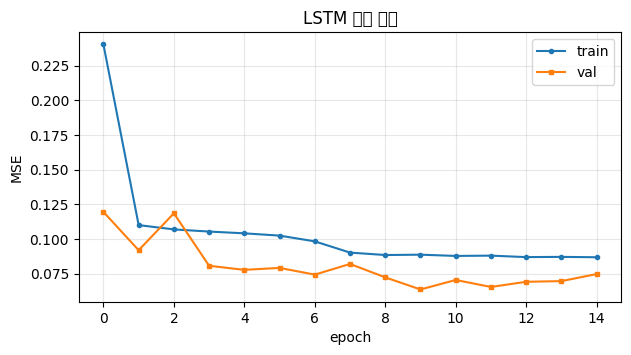

,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762
SARIMA,1.3393,1.8490,21.5928
LSTM,1.0832,1.4836,19.7136


In [19]:
class LSTMForecast(nn.Module):
    def __init__(self, H, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, H)

    def forward(self, x):                 # x: (B, L)
        out, _ = self.lstm(x.unsqueeze(-1))   # (B, L, hidden)
        # TODO: 168개 시점의 은닉 상태 중 예측에 사용할 것은 무엇일까요?
        #       (힌트: RNN 구조 그림에서 마지막 시점의 은닉 상태)
        return self.fc(out[:, -1])

torch.manual_seed(SEED)
t0 = time.time()
model_lstm, hist_lstm = train_model(LSTMForecast(H), X_tr, Y_tr, X_va, Y_va, tag="LSTM")
t_lstm = time.time() - t0
results.append(score("LSTM", predict(model_lstm, X_te)))
plot_curve(hist_lstm, "LSTM 학습 곡선")
pd.DataFrame(results).set_index("model").round(4)

## 1-9. 모델 C — LTSF-DLinear

세션에서 배운 DLinear의 3단계를 그대로 구현합니다.

```
(1) Moving Average로 데이터를 Trend(추세)와 Remainder(잔차) 성분으로 나눔
(2) 각 성분을 Linear 학습
(3) 두 레이어의 결과를 합하여 최종 예측값 생성          X̂ = H_s + H_t
```

  [DLinear] epoch   5  train=0.08316  val=0.03888
  [DLinear] epoch  10  train=0.08330  val=0.03567
  [DLinear] epoch  15  train=0.08322  val=0.03343
  [DLinear] best val loss = 0.03328  |  파라미터 8,112


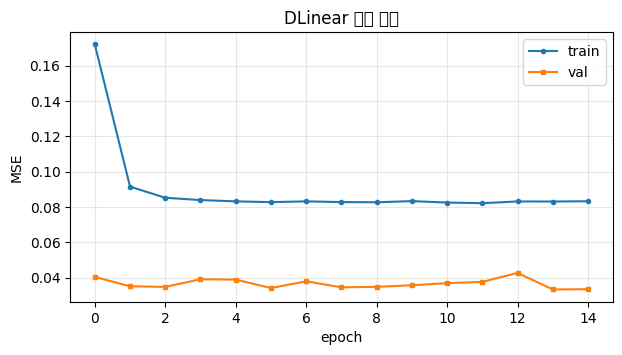

DLinear 학습 시간 6초


,MAE,RMSE,MAPE
model,,,
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762
SARIMA,1.3393,1.8490,21.5928
LSTM,1.0832,1.4836,19.7136
DLinear,1.2130,1.5945,19.7995


In [20]:
class DLinear(nn.Module):
    def __init__(self, L, H, kernel=25):   # kernel은 반드시 홀수 (짝수면 출력 길이가 1 늘어남)
        super().__init__()
        self.kernel = kernel
        self.lin_trend     = nn.Linear(L, H)   # 추세 성분용
        self.lin_remainder = nn.Linear(L, H)   # 잔차 성분용

    def series_decomp(self, x):
        """(1) 이동평균으로 Trend를 뽑고, 원본에서 빼서 Remainder를 얻습니다."""
        pad_len = self.kernel // 2
        pad   = torch.cat([x[:, :1].repeat(1, pad_len), x, x[:, -1:].repeat(1, pad_len)], dim=1)
        trend = nn.functional.avg_pool1d(pad.unsqueeze(1), self.kernel, stride=1).squeeze(1)

        # TODO: Remainder 성분은 어떻게 구하나요?
        remainder = x - trend
        return remainder, trend

    def forward(self, x):
        remainder, trend = self.series_decomp(x)
        # TODO: (3)단계입니다. 두 Linear의 출력을 어떻게 결합하나요?
        return self.lin_trend(trend) + self.lin_remainder(remainder)

torch.manual_seed(SEED)
t0 = time.time()
model_dl, hist_dl = train_model(DLinear(L, H), X_tr, Y_tr, X_va, Y_va, tag="DLinear")
t_dl = time.time() - t0
results.append(score("DLinear", predict(model_dl, X_te)))
plot_curve(hist_dl, "DLinear 학습 곡선")
print(f"DLinear 학습 시간 {t_dl:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

## 1-10. 성능 비교 및 해석

**완전히 동일한 30개 origin**에서 다섯 가지 예측을 비교합니다.

,MAE,RMSE,MAPE
model,,,
LSTM,1.0832,1.4836,19.7136
DLinear,1.2130,1.5945,19.7995
SARIMA,1.3393,1.8490,21.5928
Naive,1.4107,1.9531,22.3857
SeasonalNaive,1.8388,2.3331,29.8762


,MAE,개선율(%)
model,,
LSTM,1.0832,41.09
DLinear,1.2130,34.03
SARIMA,1.3393,27.16
Naive,1.4107,23.28
SeasonalNaive,1.8388,0.00


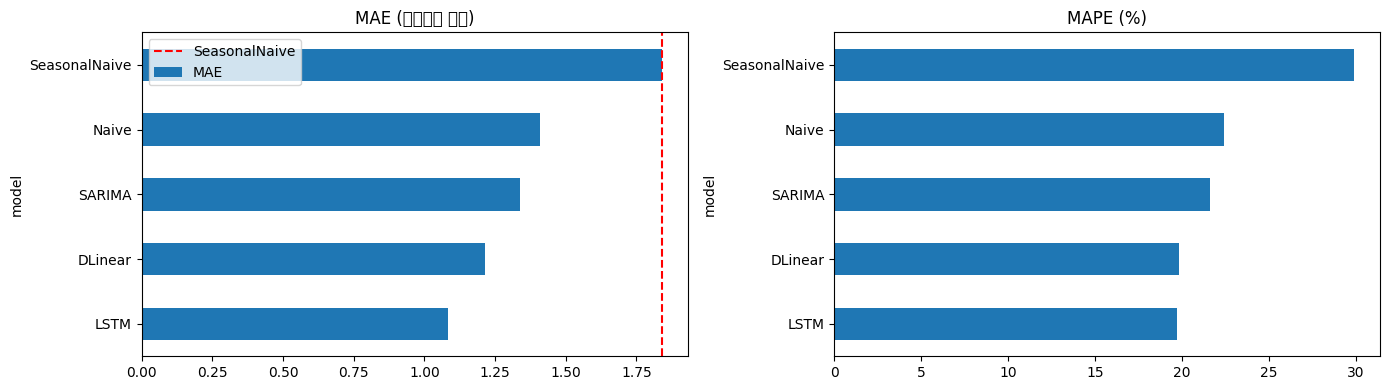

In [21]:
res = pd.DataFrame(results).set_index("model").sort_values("MAE").round(4)
display(res)

base = res.loc["SeasonalNaive", "MAE"]
res["개선율(%)"] = ((base - res["MAE"]) / base * 100).round(2)   # 베이스라인 대비
display(res[["MAE", "개선율(%)"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
res["MAE"].plot(kind="barh", ax=axes[0], title="MAE (낮을수록 좋음)")
axes[0].axvline(base, color="red", ls="--", label="SeasonalNaive"); axes[0].legend()
res["MAPE"].plot(kind="barh", ax=axes[1], title="MAPE (%)")
plt.tight_layout(); plt.show()

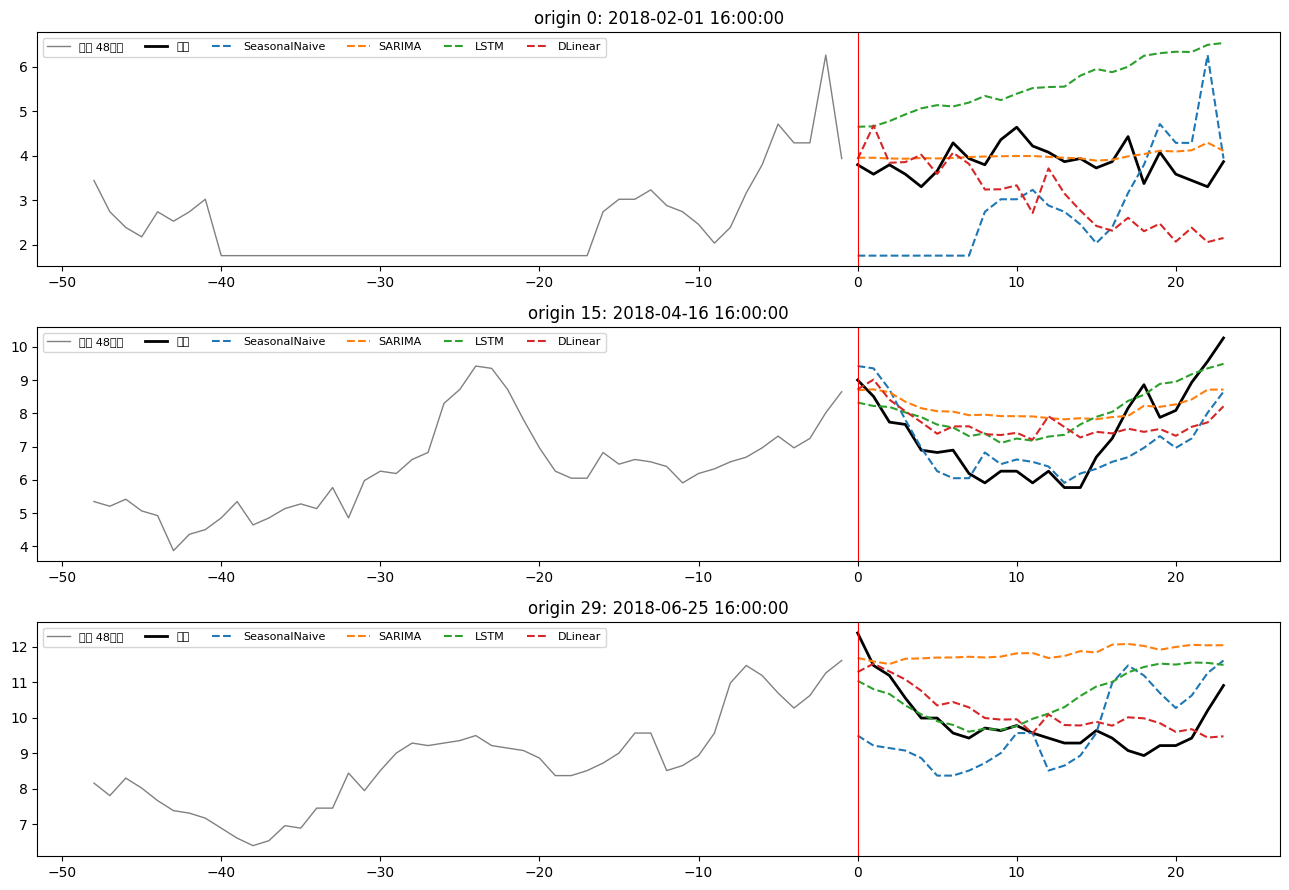

In [22]:
pred_dl, pred_lstm = predict(model_dl, X_te), predict(model_lstm, X_te)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, k in zip(axes, [0, len(origins)//2, len(origins)-1]):
    t = origins[k]
    ax.plot(range(-48, 0), y.values[t-48:t], color="gray", lw=1, label="과거 48시간")
    ax.plot(range(H), Y_TRUE[k],      "k-", lw=2, label="실제")
    ax.plot(range(H), pred_snaive[k], "--", label="SeasonalNaive")
    ax.plot(range(H), pred_sarima[k], "--", label="SARIMA")
    ax.plot(range(H), pred_lstm[k],   "--", label="LSTM")
    ax.plot(range(H), pred_dl[k],     "--", label="DLinear")
    ax.axvline(0, color="red", lw=.8); ax.set_title(f"origin {k}: {y.index[t]}")
    ax.legend(fontsize=8, ncol=6)
plt.tight_layout(); plt.show()

> ### Q4. 왜 이러한 결과가 나왔는가?
> 순위를 나열하지 말고, **데이터의 성질과 각 모델의 구조를 연결**해서 설명하세요.

이 데이터는 계절성보다 추세가 강하게 나타난다. 따라서 SeasonalNaive는 과거의 계절 패턴을 그대로 반복하기 때문에 변화하는 추세를 충분히 반영하지 못해 성능이 좋지 않았다. Naive는 가장 최근의 값을 기준으로 예측하기 때문에 변화하는 추세를 일부 반영하여 SeasonalNaive보다 나은 성능을 보였다. SARIMA는 차분을 통해 추세를 제거하고 자기상관과 계절성을 반영할 수 있지만, 선형적인 구조를 기반으로 하기 때문에 급격하거나 비선형적인 변화를 충분히 반영하는지는 못했다. 반면 DLinear는 추세 성분을 분리하여 학습하기 때문에 강한 추세가 있는 데이터에서 더 효과적이었다. LSTM은 과거 시점의 정보를 이용하여 추세와 변동의 비선형적인 관계를 함께 학습할 수 있기 때문에 가장 좋은 성능을 보였다.

> ### Q5. 세 모델의 성능 차이는 어디에서 발생했는가?
> 위 예측 곡선 그림을 근거로, **어떤 상황에서 어느 모델이 유리했는지** 구체적으로 짚으세요.
> (힌트: 평탄한 구간 / 급변 구간 / 예측 시점에서 먼 뒤쪽 시간대를 나눠서 보세요)

평탄한 구간에서는 대부분 실제값을 잘 따라갔지만, SARIMA의 예측 자체가 완만하기 때문에 우연히 맞는 것으로 보인다. 반면 실제값이 하락하는 구간에서는 SARIMA가 거의 따라가지 못하고 가장 크게 벌어졌으며, LSTM이 상대적으로 방향 전환을 더 잘 설명했다. 하지만 직접 입력 구간에 이상치가 있었던 orgin 0에서는 LSTM이 그 모멘텀을 과도하게 연장해 오히려 가장 크게 틀렸다. 예측 시점에서 멀어질수록 모든 모델의 오차가 커졌으며, 그 중 SARIMA가 가장 크게 벌여졌고 LSTM이 상대적으로 가장 근접했다.

> ### Q6. 예상과 다른 결과가 나왔다면 그 원인은 무엇인가?
> 1. 실험 전 예상과 실제 결과가 달랐던 지점을 하나 이상 쓰고 원인을 분석하세요.
> 2. **MAPE 값이 유독 크게 나왔을 수 있습니다.** 1-5에서 출력한 통계(0에 가까운 값의 비율, **음수 비율**)와 연결해 원인을 설명하고, 세션에서 배운 세 지표 중 **이 데이터에서는 무엇을 주로 봐야 하는지** 근거와 함께 제시하세요.
>    (힌트: MAPE는 오차를 실제값으로 나눕니다. 실제값이 **음수**이면 그 결과를 "오차율"이라고 부를 수 있을까요?)

1. 1-7에서 SARIMA 차수를 정할 때 계절 차분을 추가로 적용하면 계절성이 완전히 제거되어 정상성이 더 좋아질 것이라고 예상했다. 그러나 실제로는 1차 차분만으로 이미 ACF가 0.940에서 0.154로 크게 줄어들었지만, 여기에 계절 차분까지 추가하니 ACF가 오히려 -0.169로 음수로 나타났다. 이미 충분한 정상성을 확보한 상태에서 불필요한 차분을 한 번 더 적용하면 데이터를 과도하게 변형시켜 원래 없던 인위적은 음의 자기상관을 만들어낸다는 것을 알 수 있었다.
2. MAPE 값이 유독 큰 이유는 정답 값 중 0에 가까운 값이 존재하기 때문이다. MAPE는 분모가 0에 가까우면 오차 비율이 커지므로, 소수의 값이 전체 평균을 크게 왜곡한다. 또한 MAPE는 실제값이 음수이면 같은 오차율 숫자가 지점마다 반대 방향을 의미하게 되어 오차율이라는 해석 자체가 깨지는 경향이 있다. 다만 이번 test 구간은 음수 비율이 0%라 그 문제가 실제로 발생하지 않았고 왜곡의 원인은 0근처 값이다. 따라서 이 데이터에서는 MAE, RMSE가 더 적합한 지표이다.

---
# 2. 심화 과제

아래 2개 중 **최소 1개 이상** 수행하세요. 코드는 대부분 채워져 있으니 **결과 해석**에 집중하면 됩니다.

| | 주제 | 세션 | 확인하려는 것 |
|---|---|---|---|
| **심화 A** | Time-Based Split vs Walk-Forward 비교 | 06장 | 평가 구간을 어떻게 잡느냐로 결론이 바뀌는가 |
| **심화 B** | lookback 길이를 바꿔 가며 DLinear 재학습 | 05장 | 과거를 길게 볼수록 항상 좋아지는가 |

## 심화 A. 검증 전략 비교

같은 모델을 두 방식으로 평가하면 성능 추정치가 얼마나 달라지는지 확인합니다.

- **Time-Based Split** : test 구간의 **맨 앞 origin 1개**에서만 평가 (세션의 "단일 테스트 구간")
- **Walk-Forward** : 30개 origin 전체에서 평가

In [ ]:
p = predict(model_dl, X_te)
per_origin = np.abs(Y_TRUE - p).mean(axis=1)

# TODO: "Time-Based Split"은 test 구간에서 origin을 딱 1개(맨 처음)만 골라 평가하는 방식입니다.
#       per_origin 배열에서 그 origin의 결과는 어떻게 가져와야 할까요?
single_mae = per_origin[____]

print(f"Time-Based Split (origin 1개) MAE = {single_mae:.4f}")
print(f"Walk-Forward     (origin 30개) MAE = {per_origin.mean():.4f}")
print(f"origin별 MAE  최소 {per_origin.min():.4f} / 최대 {per_origin.max():.4f} / 표준편차 {per_origin.std():.4f}")

plt.figure(figsize=(11, 3.5))
plt.bar(range(len(per_origin)), per_origin)
plt.axhline(per_origin.mean(), color="red", ls="--", label=f"전체 평균 {per_origin.mean():.3f}")
plt.xlabel("origin index"); plt.ylabel("MAE"); plt.legend()
plt.title("origin별 MAE — 어느 구간을 고르느냐에 따라 결론이 달라진다")
plt.show()

## 심화 B. lookback 길이 실험

LTSF-Linear 계열은 **입력 구간(lookback)을 얼마나 주느냐**에 성능이 민감합니다. 직접 확인해 봅니다.

In [24]:
# TODO: 서로 다른 lookback 길이를 실험해 보세요. (예: 24, 96, 168, 336)
LOOKBACKS = [24, 96, 168, 336]

rows = []
for L_try in LOOKBACKS:
    Xa, Ya = make_windows(0, i_train, L_try)
    Xb, Yb = make_windows(i_train, i_val, L_try)
    Xc     = torch.tensor(np.stack([ys[t - L_try : t] for t in origins]))

    torch.manual_seed(SEED)
    m, _ = train_model(DLinear(L_try, H), Xa, Ya, Xb, Yb, epochs=15, tag=f"L={L_try}")
    s = score(f"L{L_try}", predict(m, Xc))
    rows.append({"lookback": L_try, "MAE": s["MAE"], "RMSE": s["RMSE"]})

pd.DataFrame(rows).set_index("lookback").round(4)

  [L=24] epoch   5  train=0.10027  val=0.03894
  [L=24] epoch  10  train=0.09712  val=0.03725
  [L=24] epoch  15  train=0.09683  val=0.03779
  [L=24] best val loss = 0.03672  |  파라미터 1,200
  [L=96] epoch   5  train=0.08714  val=0.03504
  [L=96] epoch  10  train=0.08627  val=0.03791
  [L=96] epoch  15  train=0.08638  val=0.03647
  [L=96] best val loss = 0.03299  |  파라미터 4,656
  [L=168] epoch   5  train=0.08316  val=0.03888
  [L=168] epoch  10  train=0.08330  val=0.03567
  [L=168] epoch  15  train=0.08322  val=0.03343
  [L=168] best val loss = 0.03328  |  파라미터 8,112
  [L=336] epoch   5  train=0.08232  val=0.03354
  [L=336] epoch  10  train=0.08197  val=0.03474
  [L=336] epoch  15  train=0.08265  val=0.04331
  [L=336] best val loss = 0.03354  |  파라미터 16,176


,MAE,RMSE
lookback,,
24,1.2785,1.7942
96,1.1921,1.5715
168,1.2130,1.5945
336,1.1785,1.5840


lookback을 늘린다고 성능이 계속 좋아지지는 않았다. L=24 -> 96에서는 MAE가 1.2785 -> 1.1921, RMSE 1.7942 -> 1.5715로 좋아졌지만 L=96 -> 168에서는 MAE가 1.1921 -> 1.2130, RMSE 1.5715 -> 1.5945로 오히려 나빠졌고 L=336에서 MAE는 1.1785로 다시 최저점을 찍었지만 RMSE는 1.5840으로 L=96 보다 좋지 않았다. 파라미터 수는 L에 비례해서 1200 -> 16176까지 늘었지만 성능은 그만큼 좋아지지는 않았다. 또한 val loss 최저점은 L=96, test MAE 최저점은 L=336으로 달라서 validation 기준 최적 lookback과 test 기준 최적 lookback이 항상 일치하지는 않는다는 것도 알 수 있다.

---
# 3. 생성형 AI 활용 방법

> **필수 작성 항목입니다.** 사용하지 않았다면 "사용하지 않음"이라고 명시하세요.

### 3-1. 활용 방법

| 항목 | 작성 |
|---|---|
| 사용한 도구 |  Claude |
| 사용한 단계 | Q1. 자기상관성과 정상성, Q6-2 |
| 사용 목적 | 개념 확인 |
| **AI 답변 중 그대로 쓰지 않고 수정한 부분** |자기상관성과 정상성이 개념을 확인하고 둘이 관계를 다시 확인했다. |
| **AI 답변이 틀렸거나 검증이 필요했던 부분** | |

### 3-2. 대화 내역

```
자기상관성과 정상성은 시계열 분석에서 가장 기본이 되는 두 개념이에요.

**자기상관성(Autocorrelation)**

한 시계열 데이터가 자기 자신의 과거 값과 얼마나 관련이 있는지를 나타내는 개념이에요. 예를 들어 오늘의 기온이 어제 기온과 비슷한 경향이 있다면, 이 시계열은 시차(lag) 1에서 양의 자기상관을 가진다고 말해요.

수식으로는 시차 k에 대한 자기상관계수를 다음과 같이 정의해요.

ρ(k) = Cov(X_t, X_{t+k}) / Var(X_t)

이 값은 -1에서 1 사이이고, 0에 가까우면 두 시점 값 사이에 선형적 관계가 거의 없다는 뜻이에요. 자기상관을 시차별로 그린 그래프를 ACF(AutoCorrelation Function) 플롯이라고 부르는데, 계절성이나 추세, 적절한 ARIMA 모델의 차수를 파악할 때 자주 사용돼요. 참고로 편자기상관함수(PACF)는 중간 시차들의 영향을 제거하고 특정 시차와의 순수한 상관관계만 보여주는 개념이라, ACF와 함께 모델 차수를 정할 때 짝을 이뤄 쓰여요.

**정상성(Stationarity)**

시계열의 통계적 성질이 시간에 따라 변하지 않는 상태를 말해요. 정상성에는 보통 두 가지 수준이 있어요.

강정상성(strict stationarity)은 시계열의 전체 확률분포 자체가 시간 이동에 대해 불변인, 매우 강한 조건이에요. 실무에서는 이보다 약한 약정상성(weak stationarity, 혹은 2차 정상성)을 주로 사용하는데, 이는 세 가지 조건을 만족해야 해요.

평균이 시간에 관계없이 일정하고, 분산도 시간에 관계없이 일정하며, 두 시점 사이의 공분산(자기공분산)이 시점 자체가 아니라 두 시점의 차이(시차)에만 의존해야 해요.

정상성이 중요한 이유는 ARIMA 같은 많은 시계열 모델이 정상성을 가정하고 만들어졌기 때문이에요. 추세나 계절성이 있는 비정상(non-stationary) 시계열을 그대로 모델링하면 예측이 부정확해지거나 허위 회귀(spurious regression) 문제가 생길 수 있어요. 그래서 실무에서는 차분(differencing), 로그 변환, 계절 차분 등을 통해 비정상 시계열을 정상 시계열로 바꾼 뒤 모델링을 진행해요. 정상성 여부는 시각적으로 그래프를 살펴보거나, ADF(Augmented Dickey-Fuller) 검정, KPSS 검정 같은 통계적 검정을 통해 확인할 수 있어요.

**두 개념의 관계**

정상 시계열에서는 자기상관계수가 시차에만 의존하고 시점 자체와는 무관하다는 성질을 갖기 때문에, 정상성은 자기상관 구조를 안정적으로 해석하고 모델링할 수 있게 해주는 전제 조건 역할을 해요. 반대로 ACF 플롯이 시차가 늘어나도 천천히 감소하지 않고 특정 패턴 없이 오래 유지된다면, 이는 시계열이 비정상일 가능성을 시사하는 단서가 되기도 해요.



실제값이 음수이면 그 결과를 오차율 이라고 부를 수 있나?

결론부터 말하면, 계산은 되지만 그걸 "오차율"이라고 부르는 건 적절하지 않다고 보는 게 일반적입니다.

MAPE는 각 시점에서 |실제값 - 예측값| / |실제값| 을 구해서 평균 낸 값이죠. 이 식이 "오차율(퍼센트 오차)"이라는 이름에 걸맞은 이유는, 분모인 실제값이 그 관측치의 "크기" 내지 "기준 스케일"을 나타낸다고 전제하기 때문입니다. 즉 오차가 실제값 대비 몇 %인지를 말하려면, 실제값이 항상 양수인 어떤 규모(scale)를 의미해야 자연스럽습니다.

그런데 실제값이 음수이면 이 전제가 깨집니다. 예를 들어 실제값이 -10, 예측값이 5라고 하면 (5-(-10))/(-10) = -1.5, 절댓값을 취하면 150%가 나옵니다. 숫자 자체는 나오지만, 이 150%가 "예측이 실제 크기보다 얼마나 벗어났는가"를 의미하는지는 불분명해집니다. 왜냐하면:

분모가 음수라서 분자의 부호 해석이 뒤틀리고, 실제값이 0에 가까운 음수일 때는 값이 폭발적으로 커질 수 있으며, 만약 데이터에 양수 실제값과 음수 실제값이 섞여 있으면 그걸 평균 내는 것 자체가 의미 없는 값들을 섞어버리는 셈이 됩니다(예: 이익/손실, 온도 변화량, 순변화율처럼 부호가 있는 지표들).

그래서 통계·예측 분야에서는 보통 "MAPE는 실제값이 0이거나 음수를 포함할 수 있는 데이터에는 정의상 부적절하다"고 명시합니다. 계산 결과 숫자가 나온다고 해도 그건 수학적 부산물일 뿐, 원래 MAPE가 의도하는 '오차율'의 의미(실제 규모 대비 오차 비율)를 갖는다고 보기 어렵습니다.

실제값에 음수가 섞여 있는 데이터라면 MAPE 대신 MAE, RMSE, 또는 MASE(Mean Absolute Scaled Error) 같은 지표를 쓰는 걸 권장하는 경우가 많습니다. 혹시 지금 다루고 계신 데이터가 어떤 종류인지(예: 손익, 온도, 재고 변화 등) 알려주시면 대안 지표 선택도 같이 봐드릴 수 있어요.
```


---
# 4. 회고

### 4-1. 가장 어려웠던 부분
>가장 어려웠던 부분은 모든 모델이 동일한 조건에서 평가받도록 origin을 생성하는 부분이었다. 처음에는 단순히 test구간에서 30개 시점을 랜덤하게 뽑으면 될것 같다고 생각했는데, 그렇게 하면 예측구간 끼리 겹치는 경우가 생겨 중복으로 평가하는 문제가 발생할 수 있다는걸 알게 되었다.
### 4-2. 세션을 들을 때와 직접 해봤을 때 다르게 이해된 부분
>세션에서는 ADF 검정 결과만 확인하면 정상성 여부를 충분히 판단할 수 있다고 생각했었는데, 직접 해보니 원본 시계열이 ADF 기준으로는 정상이라고 나와도 ACF에는 강한 계절적 패턴이 남아있는 경우가 있다는 것을 알게 되었다.